# MNIST Digit Classification with Keras

## Purpose
This notebook demonstrates how to build, train, and evaluate a neural network using Keras for classifying handwritten digits from the MNIST dataset. It covers data loading, exploration, preprocessing, and different model architectures with their training and evaluation.

**Experiment Link** --> https://colab.research.google.com/drive/1QZHwYJnqQBSCvY_LvqXaWorzDi1ZgnnV?usp=sharing

## 1. Setup and Data Loading
This section imports necessary libraries and loads the MNIST dataset using Keras.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

## 2. Data Exploration
Here, we explore the loaded dataset to understand its shape, dimensions, and visualize some sample images.

In [5]:
(train_x, train_y), (test_x, test_y) = keras.datasets.mnist.load_data()

In [6]:
train_x.shape

(60000, 28, 28)

In [7]:
train_y.shape

(60000,)

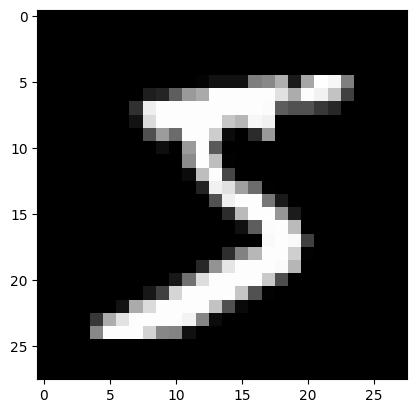

In [8]:
# Each data point is nothing but a pixel value
plt.imshow(train_x[0],cmap='gray')

In [9]:
for i in train_x[0]:
  print(i)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[  0   0   0   0   0   0   0   0   0   0   0   0   3  18  18  18 126 136
 175  26 166 255 247 127   0   0   0   0]
[  0   0   0   0   0   0   0   0  30  36  94 154 170 253 253 253 253 253
 225 172 253 242 195  64   0   0   0   0]
[  0   0   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251
  93  82  82  56  39   0   0   0   0   0]
[  0   0   0   0   0   0   0  18 219 253 253 253 253 253 198 182 247 241
   0   0   0   0   0   0   0   0   0   0]
[  0   0   0   0   0   0   0   0  80 156 107 253 253 205  11   0  43 154
   0   0   0   0   0   0   0   0   0   0]
[  0   0   0   0   0   0   0   0   0  14   1 154 253  90   0   0   0   0
   0   0   0   0   0   0   0   0   0   0]
[  0   0   0   0   0

### Helper Function to Visualize Data
This function helps in visualizing individual digits along with their corresponding labels.

In [16]:
# checking for output
def look_data(idx):
  print(f"y_lable:",train_y[idx])
  plt.imshow(train_x[idx],cmap='gray')

## 3. Data Preprocessing
This section prepares the data for model training by normalizing pixel values and reshaping the images into a flattened vector format suitable for a dense neural network.

y_lable: 9


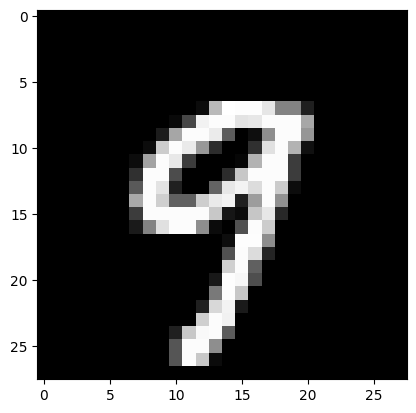

In [17]:
look_data(45)

y_lable: 1


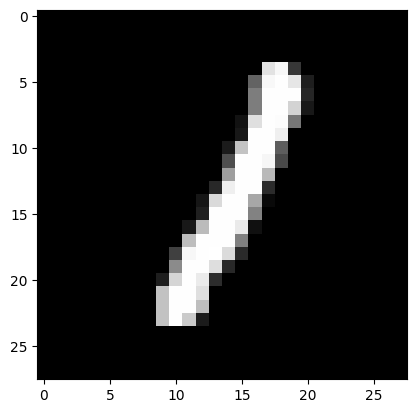

In [18]:
look_data(345)

In [21]:
# Resclae the data
max(train_x[00].flatten()),min(train_x[00].flatten())

(np.uint8(255), np.uint8(0))

In [24]:
# Normalize
train_x = train_x/255.0
test_x = test_x/255.0

In [26]:
max(train_x[10].flatten()),min(train_x[10].flatten())

(np.float64(0.996078431372549), np.float64(0.0))

## 4. Model Building and Training - First Model
We build a simple dense neural network model, compile it using SGD optimizer, and train it on the flattened data.

In [28]:
# Reshape the data
train_x_flattened = train_x.reshape(len(train_x),28*28)
test_x_flattened = test_x.reshape(len(test_x),28*28)

In [30]:
train_x.shape, train_x_flattened.shape

((60000, 28, 28), (60000, 784))

In [32]:
test_x.shape, test_x_flattened.shape

((10000, 28, 28), (10000, 784))

In [33]:
# Keras Model training
model=keras.Sequential([
    keras.layers.Dense(20,input_shape=(784,),activation='relu'),
    keras.layers.Dense(10,input_dim=784,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
model.compile(optimizer='sgd',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Evaluate First Model
After training, we evaluate the model's performance on the test set and visualize the training history (loss and accuracy over epochs).

In [36]:
# Train the model
history=model.fit(train_x_flattened,train_y,epochs=5,validation_data=(test_x_flattened,test_y))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.6562 - loss: 1.1090 - val_accuracy: 0.8677 - val_loss: 0.4713
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8823 - loss: 0.4126 - val_accuracy: 0.9006 - val_loss: 0.3494
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9033 - loss: 0.3368 - val_accuracy: 0.9096 - val_loss: 0.3115
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9141 - loss: 0.3008 - val_accuracy: 0.9171 - val_loss: 0.2862
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9207 - loss: 0.2759 - val_accuracy: 0.9234 - val_loss: 0.2697


### Visualising the First Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9234 - loss: 0.2697
Test Loss: 0.2697
Test Accuracy: 0.9234


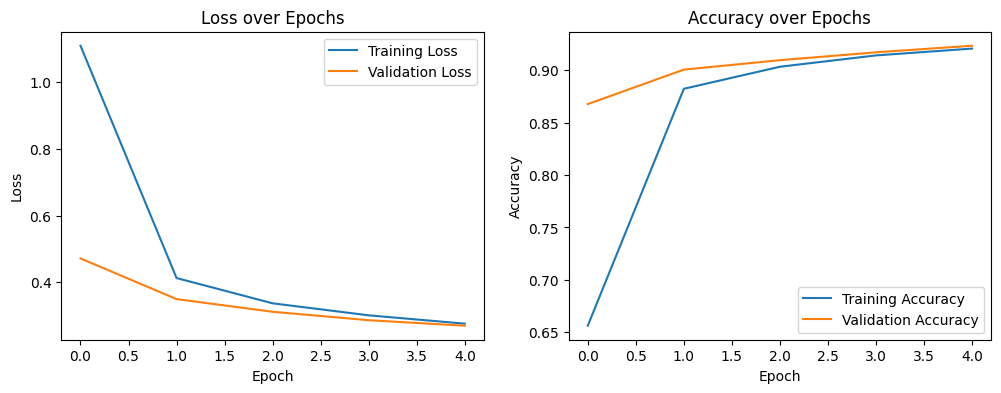

In [37]:
loss, accuracy = model.evaluate(test_x_flattened, test_y)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

After building the DL model, we evaluated it and achieved approximately 92.34% accuracy.

## 5. Model Building and Training - Second Model (with Dropout and Adam Optimizer)
This section introduces a slightly more complex model with more layers and a dropout layer to prevent overfitting. We also switch to the Adam optimizer for potentially faster and better convergence.

In [38]:
# Keras Model training with ading dropuot layer
model = keras.Sequential([
    keras.Input(shape=(784,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])
print("Model architecture updated successfully, addressing input_shape warning.")

Model architecture updated successfully, addressing input_shape warning.


In [39]:
# model compile using optimiser "adam"
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Evaluate Second Model
Similar to the first model, we evaluate the performance and visualize the training history of this enhanced model.

In [41]:
# Train the model
history=model.fit(train_x_flattened,train_y,epochs=5,validation_data=(test_x_flattened,test_y))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9098 - loss: 0.3048 - val_accuracy: 0.9590 - val_loss: 0.1348
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9613 - loss: 0.1329 - val_accuracy: 0.9684 - val_loss: 0.1008
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9719 - loss: 0.0939 - val_accuracy: 0.9733 - val_loss: 0.0918
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9781 - loss: 0.0750 - val_accuracy: 0.9766 - val_loss: 0.0808
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9810 - loss: 0.0622 - val_accuracy: 0.9780 - val_loss: 0.0806


### Visualising the Second Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0806
Test Loss: 0.0806
Test Accuracy: 0.9780


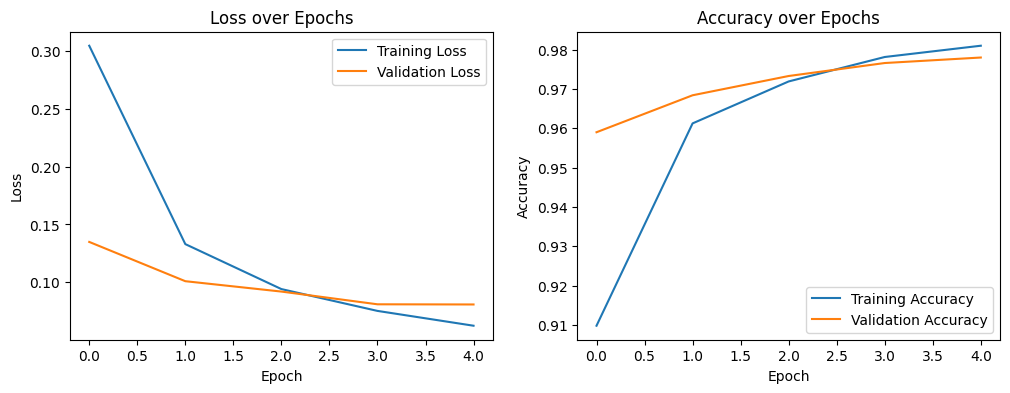

In [42]:
loss, accuracy = model.evaluate(test_x_flattened, test_y)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

After building the DL model, we evaluated it and achieved approximately 97.80% accuracy.

## 6. Model Building and Training - Third Model (without using Flatten layer)
In this iteration, we incorporate the `Flatten` layer directly into the Keras Sequential model, allowing us to feed the original 2D image data directly to the model without manual reshaping. This simplifies the preprocessing step outside the model.

In [43]:
# Build Keras model without flatenning the data
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28, 28)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [44]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

### Evaluate Third Model
Finally, we evaluate the performance of the third model and visualize its training history.

In [46]:
# Train the model
history=model.fit(train_x,train_y,epochs=5,validation_data=(test_x,test_y))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9106 - loss: 0.3049 - val_accuracy: 0.9590 - val_loss: 0.1299
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9600 - loss: 0.1339 - val_accuracy: 0.9637 - val_loss: 0.1135
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9706 - loss: 0.0977 - val_accuracy: 0.9737 - val_loss: 0.0864
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9768 - loss: 0.0767 - val_accuracy: 0.9763 - val_loss: 0.0804
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9808 - loss: 0.0629 - val_accuracy: 0.9775 - val_loss: 0.0754


### Visualising the Third Model

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9775 - loss: 0.0754
Test Loss: 0.0754
Test Accuracy: 0.9775


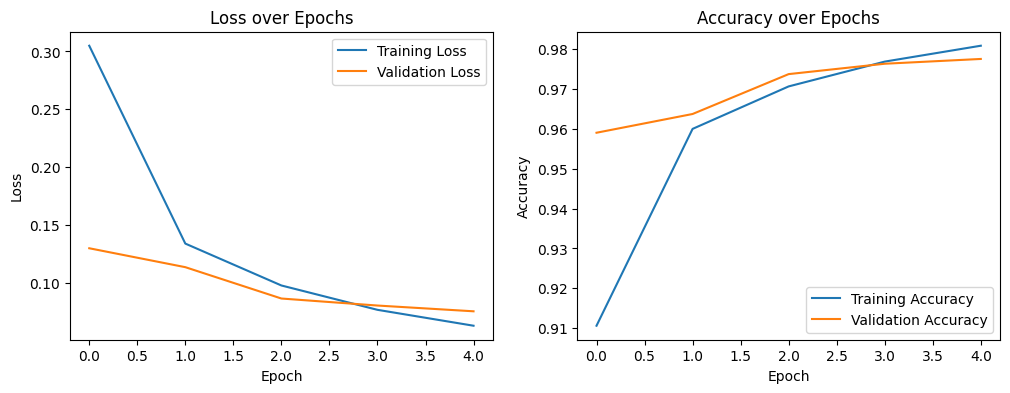

In [48]:
loss, accuracy = model.evaluate(test_x, test_y)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

After building the DL model, we evaluated it and achieved approximately 97.75% accuracy.